In [1]:
import pandas as pd 

In [2]:
import numpy as np

In [3]:
import sqlite3

In [4]:
conn=sqlite3.connect(":memory:")
cursor=conn.cursor()

In [5]:
cursor.executescript("""
CREATE TABLE users(
transaction_id INTEGER PRIMARY KEY AUTOINCREMENT,
user_id INTEGER,
signup_date TEXT,
transaction_date INTEGER,
amount REAL,
status TEXT);
""")
conn.commit()

In [6]:
cursor.executescript("""
INSERT INTO users(user_id,signup_date,transaction_date,amount,status) VALUES
(101,'2026-01-01','2026-01-05',345.00,'usa'),
(102,'2026-01-02','2026-01-06',-345.00,'USA'),
(103,'2026-01-03','2026-01-07',NULL,'uk'),
(104,'2026-01-04','2026-01-08',100.00,'canada'),
(101,'2026-01-01','2026-01-05',345.00,'usa');
""")
conn.commit()

In [7]:
df=pd.read_sql('SELECT * FROM users;',conn)

In [8]:
df

,transaction_id,user_id,signup_date,transaction_date,amount,status
0,1,101,2026-01-01,2026-01-05,345.0,usa
1,2,102,2026-01-02,2026-01-06,-345.0,USA
2,3,103,2026-01-03,2026-01-07,NaN,uk
3,4,104,2026-01-04,2026-01-08,100.0,canada
4,5,101,2026-01-01,2026-01-05,345.0,usa


In [9]:
print("-------DATA BEFORE CLEANING---------")
print(df)
print("\n")

-------DATA BEFORE CLEANING---------
   transaction_id  user_id signup_date transaction_date  amount  status
0               1      101  2026-01-01       2026-01-05   345.0     usa
1               2      102  2026-01-02       2026-01-06  -345.0     USA
2               3      103  2026-01-03       2026-01-07     NaN      uk
3               4      104  2026-01-04       2026-01-08   100.0  canada
4               5      101  2026-01-01       2026-01-05   345.0     usa




In [10]:
df['status']=df['status'].str.strip().str.upper()

In [11]:
df['amount']=np.where(df['amount']<0,np.nan,df['amount'])

In [12]:
df

,transaction_id,user_id,signup_date,transaction_date,amount,status
0,1,101,2026-01-01,2026-01-05,345.0,USA
1,2,102,2026-01-02,2026-01-06,NaN,USA
2,3,103,2026-01-03,2026-01-07,NaN,UK
3,4,104,2026-01-04,2026-01-08,100.0,CANADA
4,5,101,2026-01-01,2026-01-05,345.0,USA


In [13]:
df.isnull().sum()

transaction_id      0
user_id             0
signup_date         0
transaction_date    0
amount              2
status              0
dtype: int64

In [14]:
median_amount=df['amount'].median()
df['amount']=df['amount'].fillna(median_amount)

In [15]:
df

,transaction_id,user_id,signup_date,transaction_date,amount,status
0,1,101,2026-01-01,2026-01-05,345.0,USA
1,2,102,2026-01-02,2026-01-06,345.0,USA
2,3,103,2026-01-03,2026-01-07,345.0,UK
3,4,104,2026-01-04,2026-01-08,100.0,CANADA
4,5,101,2026-01-01,2026-01-05,345.0,USA


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df=df.drop_duplicates(subset=['user_id','transaction_date'],keep='first')

In [18]:
df

,transaction_id,user_id,signup_date,transaction_date,amount,status
0,1,101,2026-01-01,2026-01-05,345.0,USA
1,2,102,2026-01-02,2026-01-06,345.0,USA
2,3,103,2026-01-03,2026-01-07,345.0,UK
3,4,104,2026-01-04,2026-01-08,100.0,CANADA


In [19]:
import matplotlib.pyplot as plt

In [20]:
type(df['amount'][0])

numpy.float64

In [21]:
Country_Sales=df.groupby('status')['amount'].sum().reset_index()

In [22]:
Country_Sales

,status,amount
0,CANADA,100.0
1,UK,345.0
2,USA,690.0


In [23]:
Country_Sales=Country_Sales.sort_values(by='amount',ascending=False)

In [24]:
Country_Sales

,status,amount
2,USA,690.0
1,UK,345.0
0,CANADA,100.0


In [25]:
Country_Sales=Country_Sales.reset_index(drop=True)

In [26]:
Country_Sales

,status,amount
0,USA,690.0
1,UK,345.0
2,CANADA,100.0


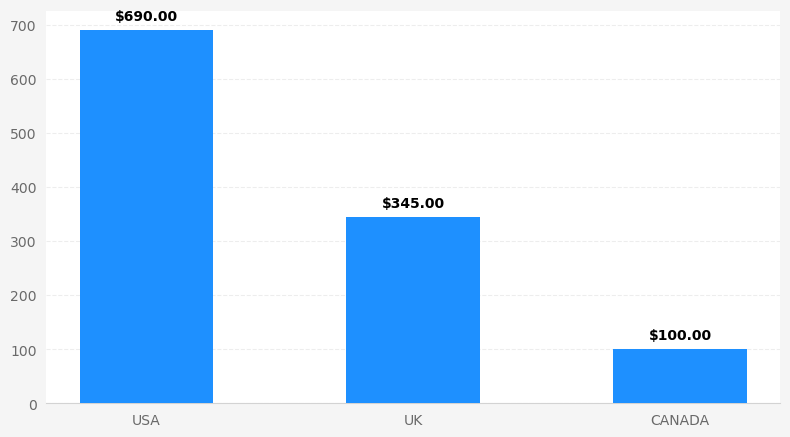

In [27]:
fig , ax=plt.subplots(figsize=(8,4.5),facecolor='whitesmoke')
ax.set_facecolor('white')
bars=ax.bar(Country_Sales['status'],Country_Sales['amount'],
           color='dodgerblue',width=0.5,zorder=3)
for spine in ['top','right','left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('lightgray')
ax.grid(axis='y',linestyle='--',alpha=0.5,color='gainsboro',zorder=0)
ax.tick_params(bottom=False,left=False,labelcolor='dimgray',labelsize=10)
for bar in bars:
    height=bar.get_height()
    ax.annotate(f"${height:,.2f}",
               xy=(bar.get_x()+ bar.get_width() / 2, height),
               xytext=(0, 5),
                textcoords="offset points",
                ha='center',va='bottom',fontsize=10,fontweight='bold',color='black')
plt.tight_layout()
plt.show()